In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# =========================
# CONFIG
# =========================
CSV_PATH = "training_log.csv"
OUTPUT_DIR = "report_plots"


In [11]:

# Set these to your actual curriculum boundaries used in training
PHASE1_TIMESTEPS = 2_000_000
PHASE2_TIMESTEPS = 3_500_000
PHASE3_TIMESTEPS = 3_000_000

PHASE2_START = PHASE1_TIMESTEPS
PHASE3_START = PHASE1_TIMESTEPS + PHASE2_TIMESTEPS



In [18]:

# =========================
# HELPERS
# =========================
def ensure_dir(path):
    Path(path).mkdir(parents=True, exist_ok=True)


def smooth_series(series, window=5):
    return series.rolling(window=window, min_periods=1).mean()


def add_phase_lines():
    plt.axvline(PHASE2_START, linestyle="--", linewidth=1)
    plt.axvline(PHASE3_START, linestyle="--", linewidth=1)


def finalize_plot(title, xlabel, ylabel, filename):
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    add_phase_lines()
    plt.tight_layout()
    plt.savefig(Path(OUTPUT_DIR) / filename, dpi=300, bbox_inches="tight")
    plt.close()


def plot_single_metric(df, x_col, y_col, title, ylabel, filename, smooth_window=5):
    if y_col not in df.columns:
        print(f"Skipping {filename}: missing column '{y_col}'")
        return

    plot_df = df[[x_col, y_col]].dropna().copy()
    if plot_df.empty:
        print(f"Skipping {filename}: no data after dropna")
        return

    plot_df[f"{y_col}_smooth"] = smooth_series(plot_df[y_col], smooth_window)

    plt.figure(figsize=(8, 5))
    plt.plot(plot_df[x_col], plot_df[y_col], alpha=0.35, label=f"{y_col} raw")
    plt.plot(plot_df[x_col], plot_df[f"{y_col}_smooth"], linewidth=2, label=f"{y_col} smoothed")
    plt.legend()
    plt.show()
    finalize_plot(title, "Timesteps", ylabel, filename)



def plot_multi_metric(df, x_col, y_cols, title, ylabel, filename, smooth_window=5):
    existing = [c for c in y_cols if c in df.columns]
    if not existing:
        print(f"Skipping {filename}: none of the columns found: {y_cols}")
        return

    plot_df = df[[x_col] + existing].dropna(subset=[x_col]).copy()
    if plot_df.empty:
        print(f"Skipping {filename}: no usable rows")
        return

    plt.figure(figsize=(8, 5))
    for col in existing:
        valid = plot_df[[x_col, col]].dropna().copy()
        if valid.empty:
            continue
        valid[f"{col}_smooth"] = smooth_series(valid[col], smooth_window)
        plt.plot(valid[x_col], valid[f"{col}_smooth"], linewidth=2, label=col)

    plt.legend()
    plt.show()
    finalize_plot(title, "Timesteps", ylabel, filename)

In [16]:



# =========================
# LOAD DATA
# =========================
ensure_dir(OUTPUT_DIR)

df = pd.read_csv(CSV_PATH)

if "timesteps_total" not in df.columns:
    raise ValueError("CSV must contain 'timesteps_total' column")

df = df.sort_values("timesteps_total").reset_index(drop=True)




print("Columns found:")
for c in df.columns:
    print(" -", c)


Columns found:
 - training_iteration
 - timesteps_total
 - episodes_total
 - time_total_s
 - episode_reward_mean
 - episode_reward_min
 - episode_reward_max
 - custom_metrics/stage_mean
 - custom_metrics/win_mean
 - custom_metrics/draw_mean
 - custom_metrics/loss_mean
 - custom_metrics/episode_length_mean
 - custom_metrics/env_reward_mean_mean
 - custom_metrics/shaping_reward_mean_mean
 - custom_metrics/proximity_reward_mean_mean
 - custom_metrics/goal_progress_reward_mean_mean
 - custom_metrics/direction_reward_mean_mean
 - custom_metrics/ball_touch_reward_mean_mean
 - custom_metrics/pressure_reward_mean_mean
 - custom_metrics/idle_defense_penalty_mean_mean
 - custom_metrics/support_reward_mean_mean
 - custom_metrics/off_ball_penalty_mean_mean
 - custom_metrics/possession_pct_mean
 - custom_metrics/field_tilt_mean
 - custom_metrics/player_distance_travelled_mean
 - custom_metrics/player_step_distance_mean_mean
 - custom_metrics/defensive_zone_pct_mean
 - custom_metrics/goal_side_pct_m

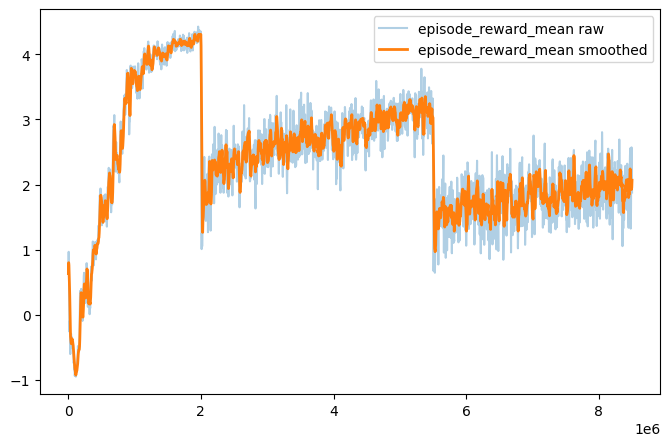

In [17]:


# =========================
# 1. MAIN TRAINING CURVE
# =========================
plot_single_metric(
    df=df,
    x_col="timesteps_total",
    y_col="episode_reward_mean",
    title="Training Curve: Episode Reward vs Timesteps",
    ylabel="Episode Reward Mean",
    filename="plot_1_training_curve.png",
    smooth_window=5,
)

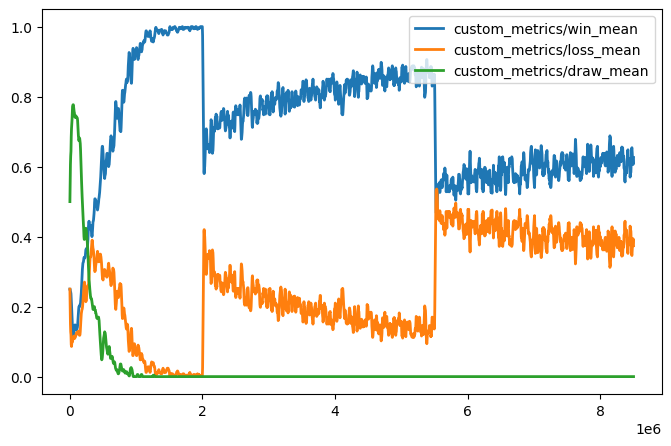

In [20]:



# =========================
# 2. WIN / LOSS / DRAW
# =========================
plot_multi_metric(
    df=df,
    x_col="timesteps_total",
    y_cols=["custom_metrics/win_mean", "custom_metrics/loss_mean", "custom_metrics/draw_mean"],
    title="Win / Loss / Draw over Training",
    ylabel="Rate",
    filename="plot_2_win_loss_draw.png",
    smooth_window=5,
)

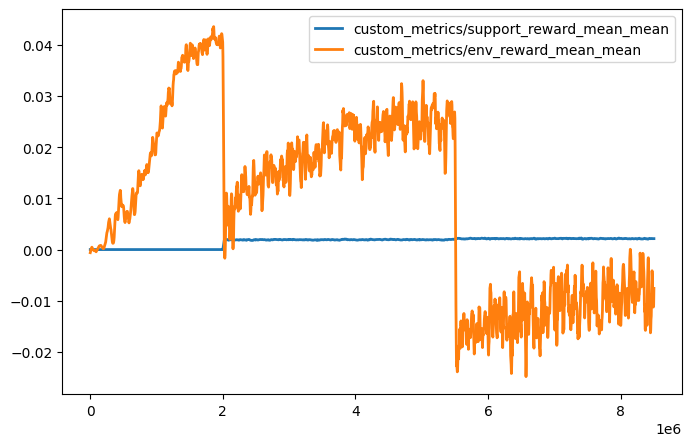

In [23]:



# =========================
# 3. SHAPING VS ENV REWARD
# =========================
plot_multi_metric(
    df=df,
    x_col="timesteps_total",
    y_cols=["custom_metrics/support_reward_mean_mean", "custom_metrics/env_reward_mean_mean"],
    title="Shaping Reward vs Environment Reward",
    ylabel="Mean Reward",
    filename="plot_3_shaping_vs_env.png",
    smooth_window=5,
)

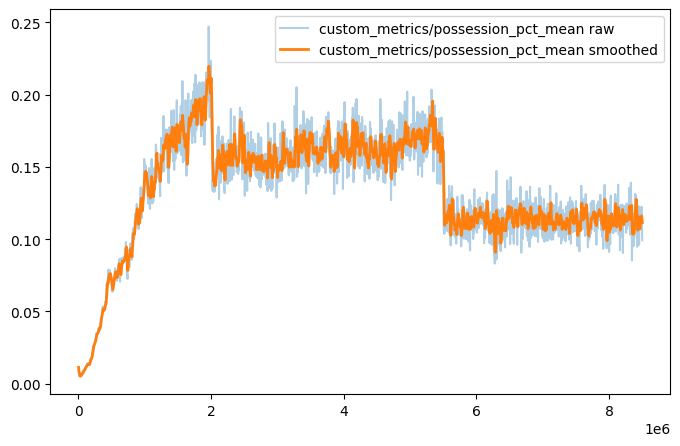

In [24]:



# =========================
# 4A. POSSESSION
# =========================
plot_single_metric(
    df=df,
    x_col="timesteps_total",
    y_col="custom_metrics/possession_pct_mean",
    title="Possession Percentage over Training",
    ylabel="Possession %",
    filename="plot_4_possession.png",
    smooth_window=5,
)


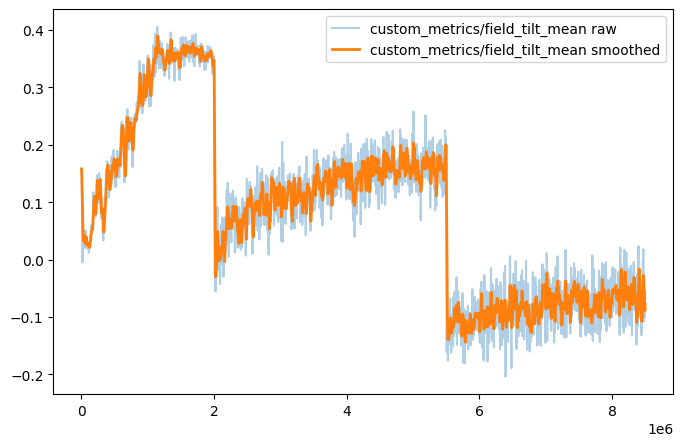

In [25]:


# =========================
# 4B. FIELD TILT
# =========================
plot_single_metric(
    df=df,
    x_col="timesteps_total",
    y_col="custom_metrics/field_tilt_mean",
    title="Field Tilt over Training",
    ylabel="Field Tilt",
    filename="plot_5_field_tilt.png",
    smooth_window=5,
)

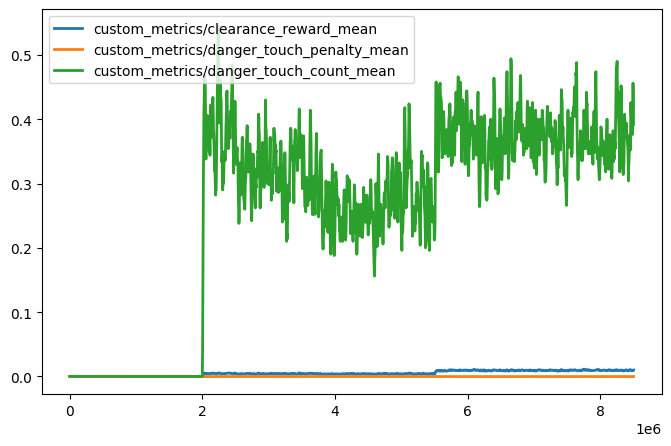

In [26]:

# =========================
# 5. DEFENSIVE METRICS
# =========================
plot_multi_metric(
    df=df,
    x_col="timesteps_total",
    y_cols=["custom_metrics/clearance_reward_mean", "custom_metrics/danger_touch_penalty_mean", "custom_metrics/danger_touch_count_mean"],
    title="Defensive Metrics over Training",
    ylabel="Metric Value",
    filename="plot_6_defensive_metrics.png",
    smooth_window=5,
)


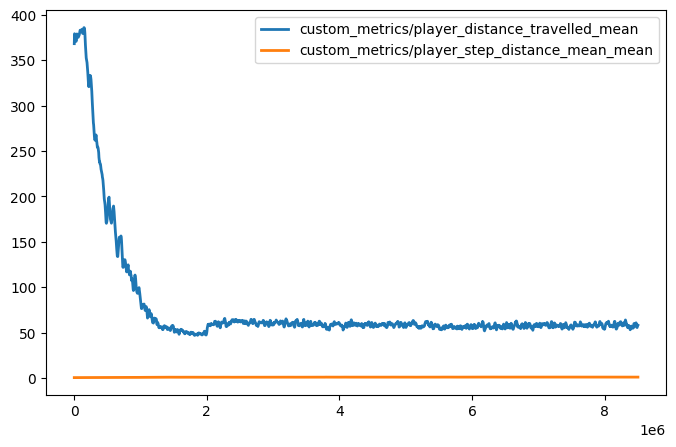

In [27]:

# =========================
# 6. PLAYER ACTIVITY
# =========================
plot_multi_metric(
    df=df,
    x_col="timesteps_total",
    y_cols=["custom_metrics/player_distance_travelled_mean", "custom_metrics/player_step_distance_mean_mean"],
    title="Player Activity over Training",
    ylabel="Movement",
    filename="plot_7_player_activity.png",
    smooth_window=5,
)


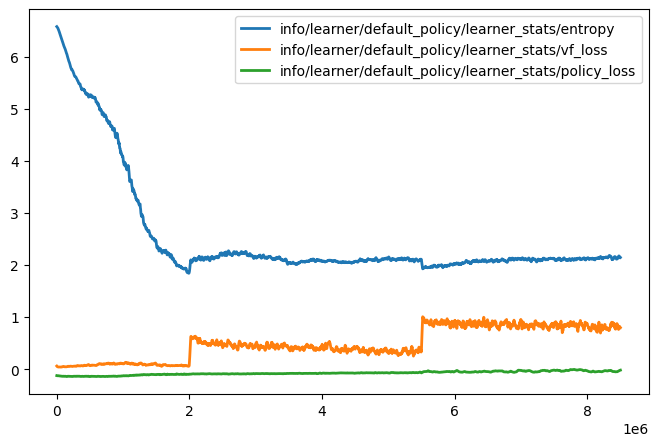

In [28]:

# =========================
# 7. PPO STABILITY
# =========================
plot_multi_metric(
    df=df,
    x_col="timesteps_total",
    y_cols=['info/learner/default_policy/learner_stats/entropy', 'info/learner/default_policy/learner_stats/vf_loss', 'info/learner/default_policy/learner_stats/policy_loss'],
    title="PPO Stability Metrics",
    ylabel="Metric Value",
    filename="plot_8_ppo_stability.png",
    smooth_window=5,
)
